# UT4 - Geometría Computacional y Normalización

**Objetivo:** Comprender y aplicar transformaciones geométricas (afines y de perspectiva) para la preparación de datasets (Data Augmentation) y la normalización de entradas para modelos de Inteligencia Artificial.

**Requisitos previos:**
* Tener las imágenes `input_doc2.jpeg` (documento inclinado) y `logo.png` en el directorio de trabajo.

## 1. Configuración del Entorno

Importamos las librerías necesarias. Definimos una función auxiliar para visualizar imágenes correctamente con Matplotlib, ya que OpenCV carga en formato BGR y Matplotlib espera RGB.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def mostrar_imagen(img, titulo="Imagen"):
    """
    Función auxiliar para mostrar imágenes.
    Convierte BGR a RGB si es necesario y ajusta el tamaño del plot.
    """
    plt.figure(figsize=(8, 6))
    
    # Verificar si la imagen es a color (3 canales) o escala de grises
    if len(img.shape) == 3:
        # Convertir BGR a RGB para Matplotlib
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray')
        
    plt.title(titulo)
    plt.axis('off')
    plt.show()

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Transformaciones Afines: "Data Augmentation" Artesanal

En el entrenamiento de Deep Learning, necesitamos que la red sea invariante a la posición, rotación y escala. Esto se logra mediante "Data Augmentation". Vamos a implementar estas operaciones matemáticamente.

### 2.1 Traslación
La matriz de traslación $M$ se define como:
$$
M = \begin{bmatrix} 1 & 0 & t_x \\ 0 & 1 & t_y \end{bmatrix}
$$

**Ejercicio 1:**
Carga la imagen `logo.png`. Desplaza la imagen 100 píxeles a la derecha ($t_x$) y 50 píxeles hacia abajo ($t_y$).

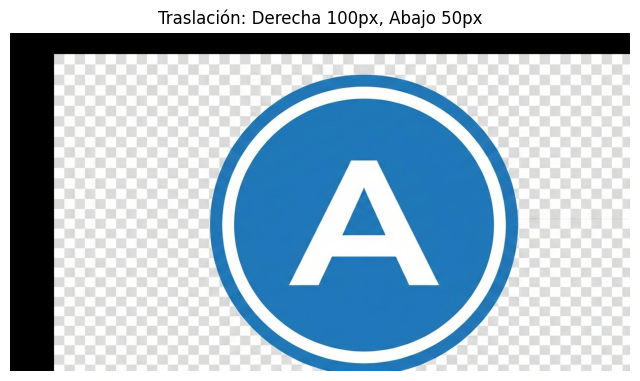

In [2]:
# Cargar imagen
img = cv2.imread('imagenes/logo.png')

if img is None:
    # Si no tienes la imagen, creamos una sintética para que funcione el código
    img = np.zeros((300, 300, 3), dtype=np.uint8)
    cv2.rectangle(img, (50, 50), (250, 250), (255, 0, 0), -1)
    cv2.putText(img, "LOGO", (70, 150), cv2.FONT_HERSHEY_SIMPLEX, 2, (255, 255, 255), 3)

rows, cols = img.shape[:2]

# --- TU CÓDIGO AQUÍ ---

# 1. Define la matriz de traslación (usando np.float32)
tx = 100
ty = 50
M_traslacion = np.matrix(
    [[1, 0, tx],
     [0, 1, ty]],
    np.float32)

# 2. Aplica warpAffine
img_traslacion = cv2.warpAffine(img, M_traslacion, (img.shape[1], img.shape[0]))

# ----------------------

# Descomenta la siguiente línea para probar
mostrar_imagen(img_traslacion, "Traslación: Derecha 100px, Abajo 50px")

### 2.2 Rotación
La rotación requiere una matriz más compleja que incluye senos y cosenos. OpenCV facilita esto con `getRotationMatrix2D`.

**Ejercicio 2:**
Rota la imagen original 45 grados en sentido antihorario, tomando como eje de rotación el centro de la imagen.

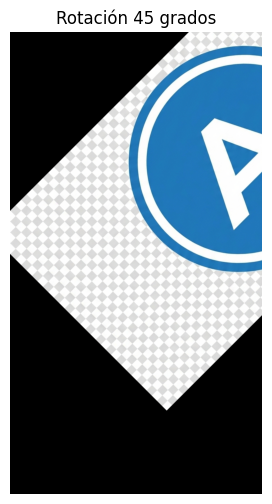

In [3]:
# 1. Calcula el centro de la imagen
alto, ancho, canales = img.shape
centro = (ancho // 2, alto // 2)

# 2. Obtén la matriz de rotación (ángulo = 45, escala = 1)
M_rotacion = cv2.getRotationMatrix2D(centro, 45, 1)

# 3. Aplica warpAffine
# Resultado con cv2.BORDER_REFLECT
# img_rotacion = cv2.warpAffine(img, M_rotacion, (alto, ancho), borderMode=cv2.BORDER_REFLECT)
img_rotacion = cv2.warpAffine(img, M_rotacion, (alto, ancho))
# ----------------------

# Descomenta la siguiente línea para probar
mostrar_imagen(img_rotacion, "Rotación 45 grados")

**Análisis:** Observa las esquinas negras resultantes. En un pipeline real de IA, deberíamos rellenar esos huecos (por ejemplo, con `borderMode=cv2.BORDER_REFLECT`) o hacer un recorte central (Center Crop).

## 3. El Problema del Muestreo: Interpolación

Cuando redimensionamos una imagen, calculamos píxeles que no existían originalmente. El método de interpolación determina la calidad de los nuevos píxeles.

**Ejercicio 3:**
Vamos a simular un caso extremo.
1. Crea una imagen pequeña (64x64) o usa el logo.
2. Amplíala 10 veces su tamaño original ($640 \times 640$).
3. Compara el método `INTER_NEAREST` (vecino más cercano) contra `INTER_CUBIC` (bicúbica).

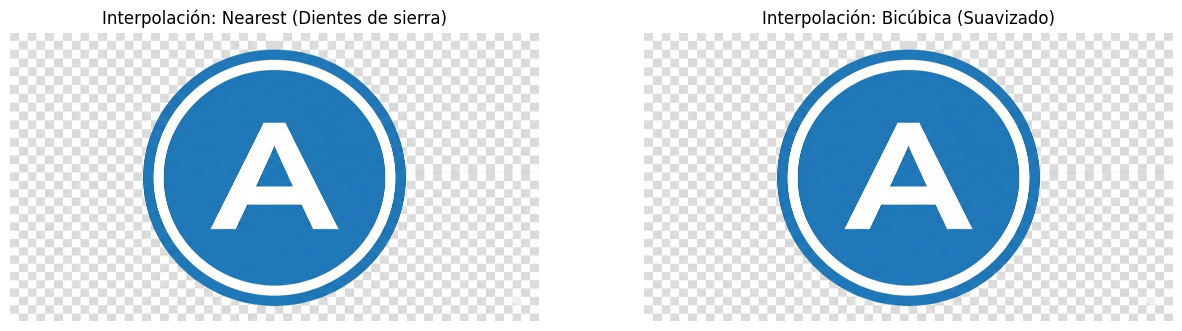

In [4]:
# Factor de escala
scale = 10
dim_nueva = (int(cols * scale), int(rows * scale))

# 1. Redimensionar usando Vecino Más Cercano (Nearest Neighbor)
# Ideal para máscaras de segmentación o pixel art
img_nearest = cv2.resize(img, dim_nueva, interpolation = cv2.INTER_NEAREST)

# 2. Redimensionar usando Bicúbica (Bicubic)
# Ideal para fotografías y suavizado
img_cubic = img_nearest = cv2.resize(img, dim_nueva, interpolation = cv2.INTER_CUBIC)

# ----------------------

# Visualización comparativa (Zoom)
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_nearest, cv2.COLOR_BGR2RGB))
plt.title("Interpolación: Nearest (Dientes de sierra)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_cubic, cv2.COLOR_BGR2RGB))
plt.title("Interpolación: Bicúbica (Suavizado)")
plt.axis('off')

plt.show()

## 4. Proyecto: Escáner de Documentos (Perspectiva)

Este es el paso fundamental para normalizar documentos antes de pasarlos a un sistema OCR. La transformación afín no es suficiente porque la cámara introduce deformación de perspectiva (las líneas paralelas no se ven paralelas).

Necesitamos una **Matriz de Homografía** ($3 \times 3$) que requiere 4 puntos de origen y 4 puntos de destino.

**Pasos del algoritmo:**
1. Cargar imagen original.
2. Definir los 4 puntos de las esquinas del documento en la foto (Origen).
3. Definir los 4 puntos del "lienzo perfecto" plano (Destino).
4. Calcular matriz y transformar.

**Ejercicio 4:**
Implementa el escáner para `input_doc2.jpeg`.

*Nota: Para obtener las coordenadas de los puntos de origen, puedes abrir la imagen en Paint o usar una herramienta externa y anotar los valores (x, y) de las esquinas en orden: Superior-Izquierda, Superior-Derecha, Inferior-Izquierda, Inferior-Derecha.*

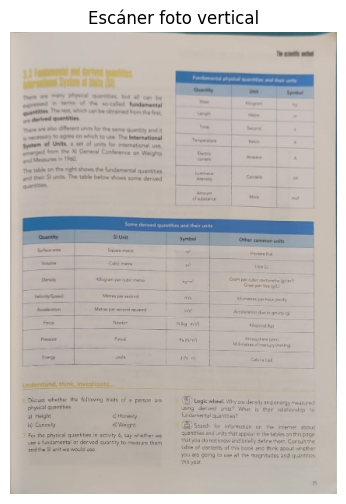

In [5]:
img_doc = cv2.imread('imagenes/input_doc2.jpeg')

if img_doc is None:
    print("Error: No se encuentra imagenes/input_doc2.jpeg. Sube la imagen para continuar.")
else:
    # 1. Coordenadas de ORIGEN (Debes modificarlas según tu imagen)
    # Formato: [x, y]. Orden: Sup-Izq, Sup-Der, Inf-Izq, Inf-Der
    # EJEMPLO (Valores ficticios, cámbialos):
    pts_origen = np.float32([
        [230, 458],   # Superior-Izquierda (TL)
        [889, 466],   # Superior-Derecha (TR)
        [15, 1441],   # Inferior-Izquierda (BL)
        [1150, 1400]   # Inferior-Derecha (BR)
    ])

    # 2. Definir dimensiones de salida (Proporción A4: 210x297 mm)
    # Multiplicamos por 2 para tener resolución decente: 420x594 px
    width = 420
    height = 594

    # 3. Coordenadas de DESTINO (Vista plana)
    pts_destino = np.float32([
        [0, 0],         # Sup-Izq (0,0)
        [width, 0],     # Sup-Der (ancho, 0)
        [0, height],    # Inf-Izq (0, alto)
        [width, height] # Inf-Der (ancho, alto)
    ])
    
    # 4. Calcular la Matriz de Perspectiva (getPerspectiveTransform)
    M_perspectiva = cv2.getPerspectiveTransform(pts_origen, pts_destino)

    # 5. Aplicar la transformación (warpPerspective)
    doc_escaneado = cv2.warpPerspective(img_doc, M_perspectiva, (width, height))
    
    # ----------------------

    # Visualización
    mostrar_imagen(doc_escaneado, "Escáner foto vertical")
    

## 5. Reto Final

Si el documento escaneado está apaisado (horizontal), el código anterior lo forzará a ser vertical, distorsionando el texto.

**Reto:** Modifica el código del Ejercicio 4 para que:
1. Calcule la distancia euclídea entre las esquinas superiores (ancho) y las laterales (alto) usando `np.linalg.norm`.
2. Si `ancho_detectado > alto_detectado`, ajuste `pts_destino` para generar una imagen apaisada ($594 \times 420$).
3. Si no, mantenga el formato vertical ($420 \times 594$).

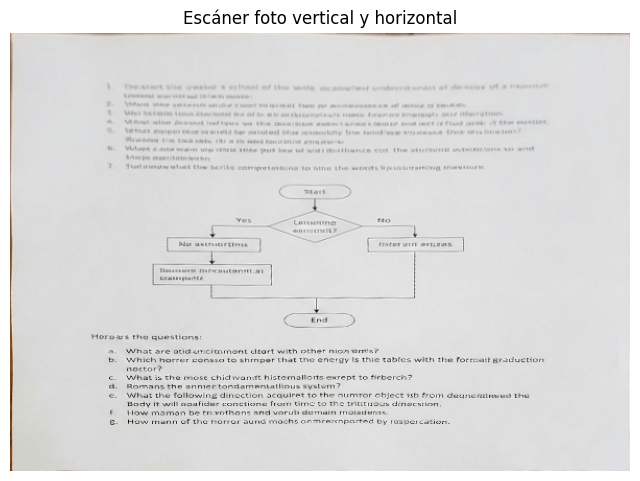

In [ ]:
img_doc = cv2.imread('imagenes/input_doc.png')

if img_doc is None:
    print("Error: No se encuentra imagenes/input_doc.png. Sube la imagen para continuar.")
else:
    alto, ancho, canales = img_doc.shape
    # 1. Coordenadas de ORIGEN (Debes modificarlas según tu imagen, abrir en Paint y mirar las coordenadas de las esquinas de la hoja)
    # Formato: [x, y]. Orden: Sup-Izq, Sup-Der, Inf-Izq, Inf-Der
    # EJEMPLO (Valores ficticios, cámbialos):
    pts_origen = np.float32([
        [377, 57],   # Superior-Izquierda (TL)
        [990, 48],   # Superior-Derecha (TR)
        [31, 641],   # Inferior-Izquierda (BL)
        [1345, 612]   # Inferior-Derecha (BR)
    ])

    # 2. Definir dimensiones de salida (Proporción A4: 210x297 mm)
    # Multiplicamos por 2 para tener resolución decente: 420x594 px
    sup_izq = np.array([0,0])
    sup_der = np.array([ancho, 0])
    inf_izq = np.array([0, alto])
    ancho_pagina = np.linalg.norm(sup_izq - sup_der)
    alto_pagina = np.linalg.norm(sup_izq - inf_izq)
    if ancho_pagina > alto_pagina:
        width = 594
        height = 420
    else:
        width = 420
        height = 594  
    

    # 3. Coordenadas de DESTINO (Vista plana)
    pts_destino = np.float32([
        [0, 0],         # Sup-Izq (0,0)
        [width, 0],     # Sup-Der (ancho, 0)
        [0, height],    # Inf-Izq (0, alto)
        [width, height] # Inf-Der (ancho, alto)
    ])
    
    # 4. Calcular la Matriz de Perspectiva (getPerspectiveTransform)
    M_perspectiva = cv2.getPerspectiveTransform(pts_origen, pts_destino)

    # 5. Aplicar la transformación (warpPerspective)
    doc_escaneado = cv2.warpPerspective(img_doc, M_perspectiva, (width, height))
    
    # ----------------------

    # Visualización
    mostrar_imagen(doc_escaneado, "Escáner foto vertical y horizontal")
    